# SANITY — GEGRU robustness to simulated scanner/site drift

Loads the trained GEGRU run (no retraining), takes the real DELCODE test
trajectories, and perturbs them with `CLASSIFIER.common.robustness.perturb_graph`
at noise levels calibrated against `site_heterogeneity_stats.json` (written by
`COMPARISON_GEGRU_CROSS_DATASET.ipynb`) to approximate ADNI-like (multi-vendor)
and OASIS3-like (single-vendor, multi-generation) site drift. Measures AUC /
sensitivity / specificity degradation vs. drift severity -- the "generalization
robustness" exhibit referenced in the cover-letter draft.

Run `COMPARISON_GEGRU_CROSS_DATASET.ipynb` first -- it computes and persists the
calibration anchor this notebook reads.


In [1]:
# === Papermill parameters ===
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None                   # adapter registry key; None -> 'gelstm' (GEGRU is rnn_type=gru)
SOURCE_EXPERIMENT = None         # GEGRU run to reload; None -> 'gegru-trajectory-whole-brain'
SITE_STATS_EXPERIMENT_ID = None  # where site_heterogeneity_stats.json lives; None -> 'comparison-gegru-cross-dataset'
SEED = 42
WANDB_ENABLED = False
OUTPUT_DIR = None
RUN_DIR = None
RUN_NAME = None


## Pipeline overview

Reload the saved `gegru-trajectory-whole-brain` run -> build the real DELCODE
test `Bundle` -> load the calibration anchor -> perturb-and-rescore at a noise
sweep for two named drift profiles -> degradation curves + ROC overlay at the
calibrated operating point.


In [2]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))


In [3]:
# reproducibility seeding -- must run before datasets / models.
from SHARED.seeding import set_seed, make_rng, make_torch_generator
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)


In [4]:
import json, os, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sk_auc

from SHARED.sanity import run_full_audit
from common.crossval import Bundle
from common.robustness import perturb_graph
from adapters import get_adapter, read_run_threshold
from adapters.explain import resolve_source_run

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Imports OK  |  device:', device)


/tmp/ipykernel_1943157/3017329666.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Imports OK  |  device: cuda


## Configuration

In [5]:
from DATA.DELCODE.src.splitting.load_splits import splits_dir, split_csv_paths

DELCODE_DATA_ROOT = str(repo_root / 'DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices')
DELCODE_METADATA_DIR = str(repo_root / 'DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata')
DELCODE_COHORTS_CSV = os.path.join(DELCODE_METADATA_DIR, 'cohorts_with_scans_on_disk.csv')
SPLITS_DIR = str(splits_dir('downstream'))
TEST_CSV = os.path.join(SPLITS_DIR, 'test.csv')

EXPERIMENT_ID = EXPERIMENT_ID or 'sanity-gegru-synthetic-scanner-drift'
OUTPUT_DIR = Path(OUTPUT_DIR) if OUTPUT_DIR else (model_root / 'outputs' / EXPERIMENT_ID / 'standalone')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SITE_STATS_EXPERIMENT_ID = SITE_STATS_EXPERIMENT_ID or 'comparison-gegru-cross-dataset'
SITE_STATS_PATH = model_root / 'outputs' / SITE_STATS_EXPERIMENT_ID / 'standalone' / 'site_heterogeneity_stats.json'
print('Output dir:', OUTPUT_DIR)


Output dir: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/sanity-gegru-synthetic-scanner-drift/standalone


In [6]:
# split-hygiene audit -- hard-fails if any subject crosses splits.
_ = run_full_audit(split_csv_paths('downstream'))


[SANITY] Split sizes: {'train': 99, 'val': 34, 'test': 34}
[SANITY] Pairwise-disjoint: OK


## Reload the trained GEGRU run

No training here -- `adapter.load_state(run_dir)` rebuilds the composite eval
state from the saved checkpoint, and `read_run_threshold` reads the
validation-derived threshold. Identical reload cell to
`COMPARISON_GEGRU_CROSS_DATASET.ipynb`.


In [7]:
SOURCE_EXPERIMENT = SOURCE_EXPERIMENT or 'gegru-trajectory-whole-brain'
RUN_DIR = resolve_source_run(SOURCE_EXPERIMENT, classifier_root=model_root)
SUMMARY = json.loads((RUN_DIR / 'run_summary.json').read_text())

# GAAE architecture + graph-construction hyperparameters (incl. adjacency_k,
# file_variant) must match what the run was trained with -- these live in the
# GAAE config, not run_summary.json's model_config (which only records the
# encoder's output shape, not how the kNN graph was built).
GAAE_CONFIG_PATH = model_root / 'configs' / 'gaae_delcode_whole_brain.json'
GAAE_HP = json.loads(GAAE_CONFIG_PATH.read_text())
GAAE_CKPT_PATH = SUMMARY['gaae_checkpoint']

adapter = get_adapter(ADAPTER or 'gelstm')(
    gaae_ckpt_path=GAAE_CKPT_PATH, gaae_hp=GAAE_HP, train_config=SUMMARY['training_config'],
    data_root=DELCODE_DATA_ROOT, cohorts_csv=DELCODE_COHORTS_CSV, device=device, rng=rng,
)
STATE = adapter.load_state(RUN_DIR)
THRESHOLD = read_run_threshold(RUN_DIR)

print(f'Reloaded {SOURCE_EXPERIMENT!r} from {RUN_DIR.name}')
print(f"Saved test AUC: {SUMMARY['metrics']['test_auc']:.4f}   "
      f"Threshold: {THRESHOLD:.4f} ({SUMMARY['threshold_method']})")


Reloaded 'gegru-trajectory-whole-brain' from lucky-harbor-3-d9655b0db-2026-06-21_13-50-00
Saved test AUC: 0.8321   Threshold: 0.6594 (oof_f1)


## Base DELCODE test trajectories

In [8]:
test_df = pd.read_csv(TEST_CSV)
BASE_BUNDLE = adapter.prepare_data(test_df)
BASELINE_METRICS = adapter.eval_split(STATE, BASE_BUNDLE, THRESHOLD, device=device)
print(f"Baseline (noise_level=0.0) DELCODE test AUC: {BASELINE_METRICS['auc']:.4f}")
print('(must match COMPARISON_GEGRU_CROSS_DATASET.ipynb\'s real DELCODE arm exactly --'
      ' perturb_graph is a no-op at noise_level=0.0.)')


LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9


[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth


Baseline (noise_level=0.0) DELCODE test AUC: 0.8321
(must match COMPARISON_GEGRU_CROSS_DATASET.ipynb's real DELCODE arm exactly -- perturb_graph is a no-op at noise_level=0.0.)


## Calibrated drift profiles

Load `site_heterogeneity_stats.json`. `base_noise_level` expresses DELCODE's own
natural inter-visit FC drift (test-retest-like) as a fraction of typical FC value
spread -- the same units `perturb_graph`'s `noise_level` parameter uses. Each
profile scales that natural floor by the cohort's real acquisition-parameter
coefficient of variation (CV = std/mean of TR across scanner records):

* **adni_like** -- `feature_noise` + `edge_perturbation`, both at
  `base_noise_level * (1 + CV_adni)` (multi-vendor: GE/Siemens/Philips => both
  amplitude and structural drift at full calibrated strength).
* **oasis3_like** -- `feature_noise` at `base_noise_level * (1 + CV_oasis3)`,
  `edge_perturbation` at half that (single-vendor Siemens, but 3 distinct model
  generations -- Biograph_mMR / TrioTim / MAGNETOM_Vida -- in the metadata, so
  some structural drift is plausible, just less than ADNI's).


In [9]:
if not SITE_STATS_PATH.is_file():
    raise FileNotFoundError(
        f"{SITE_STATS_PATH} not found -- run COMPARISON_GEGRU_CROSS_DATASET.ipynb "
        "first (it computes and persists the calibration anchor this notebook reads)."
    )
SITE_STATS = json.loads(SITE_STATS_PATH.read_text())
BASE_NOISE_LEVEL = SITE_STATS['base_noise_level']
CALIBRATED_LEVEL = {
    'adni_like':   BASE_NOISE_LEVEL * (1 + SITE_STATS['adni_tr_cv']),
    'oasis3_like': BASE_NOISE_LEVEL * (1 + SITE_STATS['oasis3_tr_cv']),
}
print('Calibration anchor:', json.dumps(SITE_STATS, indent=2))
print('Calibrated operating points:', CALIBRATED_LEVEL)

def perturb_item(item, profile, level, prng):
    graphs = []
    edge_level = level if profile == 'adni_like' else level / 2.0
    for g in item['graphs']:
        g = perturb_graph(g, 'feature_noise', level, rng=prng)
        g = perturb_graph(g, 'edge_perturbation', edge_level, rng=prng)
        graphs.append(g)
    return {**item, 'graphs': graphs}

def perturb_bundle(bundle, profile, level, seed):
    prng = make_rng(seed)
    items = [perturb_item(it, profile, level, prng) for it in bundle.items]
    return Bundle(bundle.labels, bundle.groups, items)


Calibration anchor: {
  "delcode_consecutive_visit_fc_delta_std": 0.2635538876056671,
  "typical_fc_std": 0.26554680713499434,
  "base_noise_level": 0.9924950348647419,
  "adni_tr_cv": 0.38145576325718394,
  "oasis3_tr_cv": 0.35847226323162534,
  "note": "base_noise_level = DELCODE natural inter-visit FC-delta std / typical FC value std (a perturb_graph-noise_level-unit drift floor). CV = std/mean of acquisition TR across scanner records, restricted to resting-state BOLD series for OASIS3 (its metadata otherwise mixes in T1/DTI/fieldmap/ASL TRs from unrelated sequence types). The drift notebook sets noise_level_<site> = base_noise_level * (1 + CV_<site>)."
}
Calibrated operating points: {'adni_like': 1.3710879859180374, 'oasis3_like': 1.3482769762588567}


## Drift sweep

In [10]:
NOISE_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
PROFILES = ['adni_like', 'oasis3_like']

rows = []
for profile in PROFILES:
    levels = sorted(set(NOISE_LEVELS) | {round(CALIBRATED_LEVEL[profile], 6)})
    for level in levels:
        bundle = BASE_BUNDLE if level == 0.0 else perturb_bundle(BASE_BUNDLE, profile, level, SEED)
        metrics = adapter.eval_split(STATE, bundle, THRESHOLD, device=device)
        rows.append({
            'profile': profile, 'noise_level': level,
            'is_calibrated_point': bool(np.isclose(level, CALIBRATED_LEVEL[profile])),
            'auc': metrics['auc'], 'sensitivity': metrics['sensitivity'],
            'specificity': metrics['specificity'], 'f1': metrics['f1'],
            'mean_prob': float(np.mean(metrics['probs'])),
        })

DRIFT_DF = pd.DataFrame(rows).sort_values(['profile', 'noise_level']).reset_index(drop=True)
DRIFT_DF


,profile,noise_level,is_calibrated_point,auc,sensitivity,specificity,f1,mean_prob
0,adni_like,0.000000,False,0.832143,0.642857,0.75,0.642857,0.498135
1,adni_like,0.100000,False,0.878571,0.714286,0.75,0.689655,0.532144
2,adni_like,0.200000,False,0.871429,0.714286,0.75,0.689655,0.530411
3,adni_like,0.300000,False,0.878571,0.714286,0.80,0.714286,0.518210
4,adni_like,0.400000,False,0.878571,0.714286,0.80,0.714286,0.496884
5,adni_like,0.500000,False,0.871429,0.714286,0.80,0.714286,0.469922
6,adni_like,1.371088,True,0.700000,0.071429,1.00,0.133333,0.138683
7,oasis3_like,0.000000,False,0.832143,0.642857,0.75,0.642857,0.498135
8,oasis3_like,0.100000,False,0.853571,0.642857,0.75,0.642857,0.512152
9,oasis3_like,0.200000,False,0.878571,0.714286,0.75,0.689655,0.527101


## Degradation curves

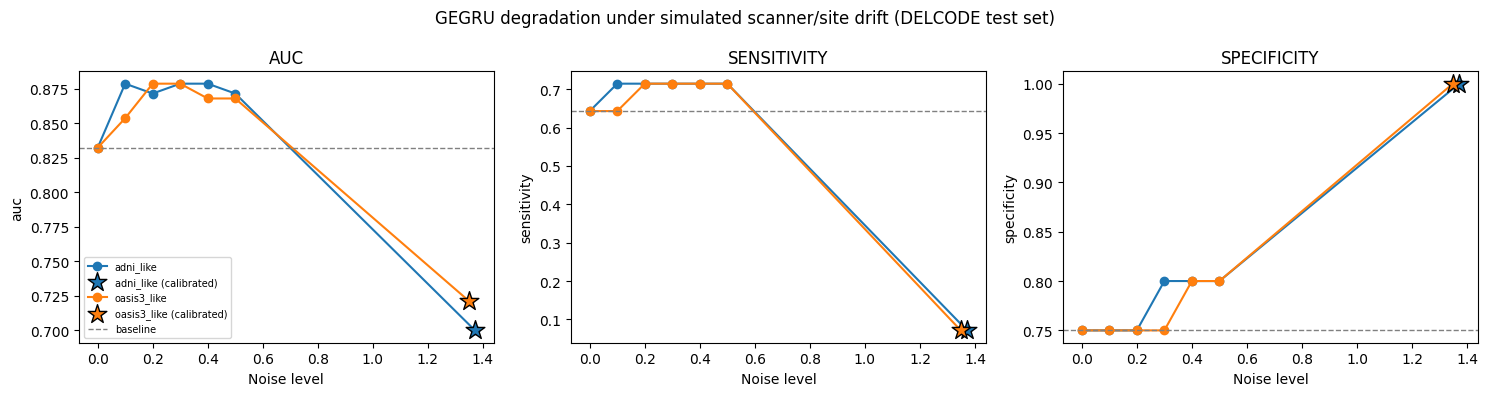

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['auc', 'sensitivity', 'specificity']):
    for profile in PROFILES:
        sub = DRIFT_DF[DRIFT_DF['profile'] == profile]
        ax.plot(sub['noise_level'], sub[metric], marker='o', label=profile)
        calib = sub[sub['is_calibrated_point']]
        ax.scatter(calib['noise_level'], calib[metric], marker='*', s=200, zorder=5,
                   edgecolor='black', label=f'{profile} (calibrated)')
    ax.axhline(BASELINE_METRICS[metric], linestyle='--', color='grey', linewidth=1, label='baseline')
    ax.set_xlabel('Noise level'); ax.set_ylabel(metric); ax.set_title(metric.upper())
axes[0].legend(fontsize=7, loc='lower left')
fig.suptitle('GEGRU degradation under simulated scanner/site drift (DELCODE test set)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'drift_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## ROC: baseline vs. calibrated drift

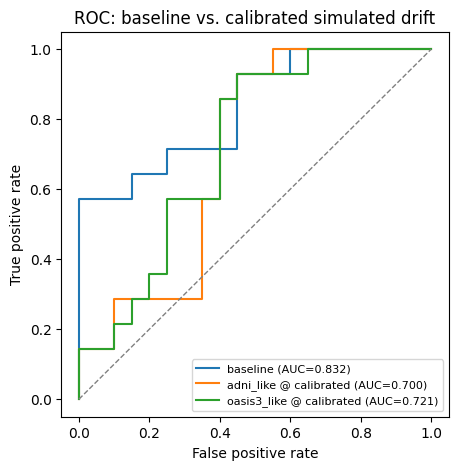

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
fpr, tpr, _ = roc_curve(BASELINE_METRICS['targets'], BASELINE_METRICS['probs'])
ax.plot(fpr, tpr, label=f'baseline (AUC={sk_auc(fpr, tpr):.3f})')
for profile in PROFILES:
    bundle = perturb_bundle(BASE_BUNDLE, profile, CALIBRATED_LEVEL[profile], SEED)
    metrics = adapter.eval_split(STATE, bundle, THRESHOLD, device=device)
    fpr, tpr, _ = roc_curve(metrics['targets'], metrics['probs'])
    ax.plot(fpr, tpr, label=f'{profile} @ calibrated (AUC={sk_auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC: baseline vs. calibrated simulated drift')
ax.legend(fontsize=8)
fig.savefig(FIGURES_DIR / 'drift_roc_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


## Save sweep results

In [13]:
DRIFT_DF.to_csv(OUTPUT_DIR / 'drift_sweep.csv', index=False)

SWEEP_SUMMARY = {
    'source_experiment': SOURCE_EXPERIMENT,
    'baseline': {k: BASELINE_METRICS[k] for k in ('auc', 'sensitivity', 'specificity', 'f1')},
    'calibrated_levels': CALIBRATED_LEVEL,
    'calibrated_metrics': {
        profile: DRIFT_DF[(DRIFT_DF['profile'] == profile) & DRIFT_DF['is_calibrated_point']]
                          .iloc[0][['auc', 'sensitivity', 'specificity', 'f1']].to_dict()
        for profile in PROFILES
    },
}
with open(OUTPUT_DIR / 'drift_summary.json', 'w') as f:
    json.dump(SWEEP_SUMMARY, f, indent=2, default=float)
print(json.dumps(SWEEP_SUMMARY, indent=2, default=float))


{
  "source_experiment": "gegru-trajectory-whole-brain",
  "baseline": {
    "auc": 0.8321428571428572,
    "sensitivity": 0.6428571428571429,
    "specificity": 0.75,
    "f1": 0.6428571428571429
  },
  "calibrated_levels": {
    "adni_like": 1.3710879859180374,
    "oasis3_like": 1.3482769762588567
  },
  "calibrated_metrics": {
    "adni_like": {
      "auc": 0.7,
      "sensitivity": 0.07142857142857142,
      "specificity": 1.0,
      "f1": 0.13333333333333333
    },
    "oasis3_like": {
      "auc": 0.7214285714285714,
      "sensitivity": 0.07142857142857142,
      "specificity": 1.0,
      "f1": 0.13333333333333333
    }
  }
}
